In [9]:
# 유전자 알고리즘 기반 로봇 경로 탐색 알고리즘 구현
# 논문: "유전자 알고리즘의 수렴 속도 향상을 통한 효과적인 로봇 길찾기 알고리즘"

import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time
from copy import deepcopy

# 랜덤 시드 설정
np.random.seed(42)
random.seed(42)

In [10]:
def create_map():
    """그림 2의 10x10 지도 생성"""
    # 10x10 빈 지도 생성 (0: 빈 공간, 1: 장애물)
    map_data = np.zeros((10, 10))
    
    # 그림 2의 장애물 위치 설정
    obstacles = [(0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), 
                (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), 
                (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), 
                (7, 1), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (7, 7), (7, 8), (7, 9)]
    
    for i, j in obstacles:
        map_data[i, j] = 1
    
    return map_data

def visualize_map(map_data, path=None, title="Map"):
    """지도와 경로 시각화"""
    plt.figure(figsize=(8, 8))
    plt.imshow(map_data, cmap='binary')
    
    # 격자 표시
    for i in range(map_data.shape[0] + 1):
        plt.axhline(i - 0.5, color='gray', linestyle='-', alpha=0.3)
        plt.axvline(i - 0.5, color='gray', linestyle='-', alpha=0.3)
    
    # 노드 번호 부여
    for i in range(map_data.shape[0]):
        for j in range(map_data.shape[1]):
            node_num = i * map_data.shape[1] + j + 1
            plt.text(j, i, f'{node_num}', ha='center', va='center', 
                     color='white' if map_data[i, j] == 1 else 'black')
    
    # 경로가 있으면 표시
    if path:
        path_coords = []
        for node in path:
            row = (node - 1) // map_data.shape[1]
            col = (node - 1) % map_data.shape[1]
            path_coords.append((col, row))
        
        # 경로 표시
        x_coords = [x for x, y in path_coords]
        y_coords = [y for x, y in path_coords]
        plt.plot(x_coords, y_coords, 'r-', linewidth=2)
        plt.plot(x_coords, y_coords, 'bo', markersize=8)
        
        # 시작점과 목표점 표시
        plt.plot(x_coords[0], y_coords[0], 'go', markersize=10)
        plt.plot(x_coords[-1], y_coords[-1], 'mo', markersize=10)
    
    plt.title(title)
    plt.grid(True)
    plt.xticks(range(map_data.shape[1]))
    plt.yticks(range(map_data.shape[0]))
    plt.show()

In [11]:
def node_to_coord(node_num, map_size=10):
    """노드 번호를 좌표로 변환"""
    row = (node_num - 1) // map_size
    col = (node_num - 1) % map_size
    return row, col

def coord_to_node(row, col, map_size=10):
    """좌표를 노드 번호로 변환"""
    return row * map_size + col + 1

def euclidean_distance(node1, node2, map_size=10):
    """두 노드 사이의 유클리드 거리 계산"""
    row1, col1 = node_to_coord(node1, map_size)
    row2, col2 = node_to_coord(node2, map_size)
    return np.sqrt((row1 - row2) ** 2 + (col1 - col2) ** 2)

def is_safe_edge(node1, node2, map_data):
    """두 노드를 연결하는 간선이 안전한지 확인"""
    row1, col1 = node_to_coord(node1)
    row2, col2 = node_to_coord(node2)
    
    # 브레젠험 알고리즘으로 선 그리기
    steep = abs(col2 - col1) < abs(row2 - row1)
    if steep:
        col1, row1 = row1, col1
        col2, row2 = row2, col2
    
    if col1 > col2:
        col1, col2 = col2, col1
        row1, row2 = row2, row1
    
    dx = col2 - col1
    dy = abs(row2 - row1)
    error = dx // 2
    ystep = 1 if row1 < row2 else -1
    y = row1
    
    for x in range(col1, col2 + 1):
        coord = (y, x) if steep else (x, y)
        if map_data[coord] == 1:  # 장애물이면
            return False
        
        error -= dy
        if error < 0:
            y += ystep
            error += dx
    
    return True

def evaluate_path(path, map_data):
    """경로 평가 (거리 계산)"""
    if not path:
        return float('inf')
    
    distance = 0
    penalty = 1000  # 장애물을 지나가는 경우의 페널티
    
    for i in range(len(path) - 1):
        distance += euclidean_distance(path[i], path[i+1])
        if not is_safe_edge(path[i], path[i+1], map_data):
            distance += penalty
    
    return distance

def random_walk(start, goal, map_data, max_steps=100):
    """무작위 이동으로 안전한 경로 생성"""
    current = start
    path = [current]
    steps = 0
    
    while current != goal and steps < max_steps:
        row, col = node_to_coord(current)
        possible_moves = []
        
        # 8방향으로 이동 가능한지 확인
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                
                new_row, new_col = row + dr, col + dc
                
                if (0 <= new_row < map_data.shape[0] and 
                    0 <= new_col < map_data.shape[1] and 
                    map_data[new_row, new_col] == 0):
                    
                    new_node = coord_to_node(new_row, new_col)
                    if is_safe_edge(current, new_node, map_data):
                        possible_moves.append(new_node)
        
        # 가능한 이동이 없으면
        if not possible_moves:
            if len(path) <= 1:
                return None  # 시작점에서 움직일 수 없음
            
            # 뒤로 돌아가기
            path.pop()
            current = path[-1]
            steps += 1
            continue
        
        # 목표 지점이 가능한 이동 중에 있으면 바로 이동
        if goal in possible_moves:
            path.append(goal)
            break
        
        # 무작위로 이동
        next_node = random.choice(possible_moves)
        path.append(next_node)
        current = next_node
        steps += 1
    
    # 목표에 도달했는지 확인
    if current != goal:
        return None
    
    return path

def initialize_population(start, goal, map_data, pop_size=50):
    """초기 경로 집합 생성"""
    population = []
    
    while len(population) < pop_size:
        path = random_walk(start, goal, map_data)
        if path:
            population.append(path)
    
    return population

In [12]:
class ProposedGA:
    def __init__(self, map_data, start, goal, pop_size=50, max_gen=100):
        self.map_data = map_data
        self.start = start
        self.goal = goal
        self.pop_size = pop_size
        self.max_gen = max_gen
        self.crossover_rate = 0.8
        self.mutation_rate = 0.2
        self.shortcut_rate = 0.5
        self.population = initialize_population(start, goal, map_data, pop_size)
        self.best_path = None
        self.best_distance = float('inf')
        self.best_history = []
    
    def crossover(self, path1, path2):
        """이점 교차 연산자"""
        if len(path1) <= 2 or len(path2) <= 2:
            return path1.copy()
        
        # 교차점 선택
        point1 = random.randint(1, len(path1) - 2)
        point2 = random.randint(1, len(path2) - 2)
        
        if point1 > point2:
            point1, point2 = point2, point1
            
        # 새로운 경로 생성
        new_path = path1[:point1] + path2[point1:point2] + path1[point2:]
        
        # 안전성 확인
        for i in range(len(new_path) - 1):
            if not is_safe_edge(new_path[i], new_path[i+1], self.map_data):
                return path1.copy()  # 안전하지 않으면 원래 경로 반환
        
        return new_path
    
    def mutation(self, path):
        """돌연변이 연산자"""
        if len(path) <= 2:
            return path.copy()
        
        # 무작위로 한 정점 선택
        point = random.randint(1, len(path) - 2)
        
        # 가능한 새로운 노드 찾기
        row, col = node_to_coord(path[point])
        
        possible_nodes = []
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                new_row, new_col = row + dr, col + dc
                if (0 <= new_row < self.map_data.shape[0] and
                    0 <= new_col < self.map_data.shape[1] and
                    self.map_data[new_row, new_col] == 0):
                    
                    new_node = coord_to_node(new_row, new_col)
                    if (is_safe_edge(path[point-1], new_node, self.map_data) and
                        is_safe_edge(new_node, path[point+1], self.map_data)):
                        possible_nodes.append(new_node)
        
        if not possible_nodes:
            return path.copy()
        
        # 무작위로 새 노드 선택
        new_path = path.copy()
        new_path[point] = random.choice(possible_nodes)
        
        return new_path
    
    def shortcut(self, path):
        """단축 연산자 - 경로 내부의 두 정점을 선택하고 그 사이 구간을 삭제"""
        if len(path) <= 3:
            return path.copy()
        
        # 선택 확률 계산
        l = len(path)
        probs = []
        
        for i in range(l):
            g_i = -abs(i - (l+1)/2) + (l-1)/2
            probs.append(g_i)
        
        # 양수로 만들기
        min_prob = min(probs)
        if min_prob < 0:
            probs = [p - min_prob for p in probs]
        
        # 확률 정규화
        sum_probs = sum(probs)
        if sum_probs > 0:
            probs = [p / sum_probs for p in probs]
        else:
            probs = [1/l] * l
        
        # 두 정점 선택
        try:
            indices = np.random.choice(range(l), size=2, replace=False, p=probs)
            idx1, idx2 = min(indices), max(indices)
        except ValueError:
            return path.copy()
        
        # 두 정점 사이의 간선이 안전한지 확인
        if idx2 - idx1 > 1 and is_safe_edge(path[idx1], path[idx2], self.map_data):
            # 사이 구간 삭제
            new_path = path[:idx1+1] + path[idx2:]
            return new_path
        
        return path.copy()
    
    def evolve(self):
        """유전자 알고리즘 진행"""
        print(f"시작: ProposedGA - 초기 최단 경로 거리: {min([evaluate_path(path, self.map_data) for path in self.population]):.2f}")
        last_best = float('inf')
        significant_improvements = 0
        
        for gen in range(self.max_gen):
            # 새로운 경로 생성
            new_population = []
            
            while len(new_population) < self.pop_size:
                # 부모 경로 선택
                parent = random.choice(self.population)
                
                # 유전자 연산자 적용
                child = parent.copy()
                
                # 교차
                if random.random() < self.crossover_rate:
                    parent2 = random.choice(self.population)
                    child = self.crossover(child, parent2)
                
                # 돌연변이
                if random.random() < self.mutation_rate:
                    child = self.mutation(child)
                
                # 단축
                if random.random() < self.shortcut_rate:
                    child = self.shortcut(child)
                
                new_population.append(child)
            
            # 모든 경로 병합 및 평가
            all_paths = self.population + new_population
            all_distances = [evaluate_path(path, self.map_data) for path in all_paths]
            
            # 거리순으로 정렬
            sorted_indices = np.argsort(all_distances)
            
            # 다음 세대 선택
            self.population = [all_paths[i] for i in sorted_indices[:self.pop_size]]
            
            # 최적 경로 업데이트
            current_best = min(all_distances)
            if current_best < self.best_distance:
                best_idx = all_distances.index(current_best)
                self.best_path = all_paths[best_idx].copy()
                self.best_distance = current_best
                
                # 유의미한 개선이 있었는지 체크 (5% 이상 개선)
                improvement = (last_best - current_best) / last_best if last_best != float('inf') else 1.0
                if improvement > 0.05:  # 5% 이상 개선
                    significant_improvements += 1
                    print(f"  ⭐ 세대 {gen}: 유의미한 개선! {last_best:.2f} → {current_best:.2f} (개선율: {improvement:.2%})")
                
                last_best = current_best
            
            self.best_history.append(self.best_distance)
            
            # 진행 상황 로그
            if gen % 10 == 0 or gen == self.max_gen - 1:
                # 경로 길이 통계 계산
                avg_distance = sum(all_distances[:self.pop_size]) / self.pop_size
                diversity = max(all_distances[:self.pop_size]) - min(all_distances[:self.pop_size])
                
                print(f"  세대 {gen:3d}/{self.max_gen-1}: 최단={self.best_distance:.2f}, 평균={avg_distance:.2f}, 다양성={diversity:.2f}, 경로길이={len(self.best_path)}")
        
        print(f"완료: ProposedGA - 최종 최단 경로 거리: {self.best_distance:.2f}, 유의미한 개선 횟수: {significant_improvements}")
        return self.best_path, self.best_distance

In [13]:
class FGA:
    def __init__(self, map_data, start, goal, pop_size=50, max_gen=100):
        self.map_data = map_data
        self.start = start
        self.goal = goal
        self.pop_size = pop_size
        self.max_gen = max_gen
        self.crossover_rate = 0.8
        self.mutation_rate = 0.2
        self.population = initialize_population(start, goal, map_data, pop_size)
        self.best_path = None
        self.best_distance = float('inf')
        self.best_history = []
    
    def crossover(self, path1, path2):
        """이점 교차 연산자"""
        if len(path1) <= 2 or len(path2) <= 2:
            return path1.copy()
        
        # 교차점 선택
        point1 = random.randint(1, len(path1) - 2)
        point2 = random.randint(1, len(path2) - 2)
        
        if point1 > point2:
            point1, point2 = point2, point1
            
        # 새로운 경로 생성
        new_path = path1[:point1] + path2[point1:point2] + path1[point2:]
        
        # 안전성 확인
        for i in range(len(new_path) - 1):
            if not is_safe_edge(new_path[i], new_path[i+1], self.map_data):
                return path1.copy()  # 안전하지 않으면 원래 경로 반환
        
        return new_path
    
    def mutation(self, path):
        """FGA의 돌연변이 연산자"""
        if len(path) <= 2:
            return path.copy()
        
        # 무작위로 한 정점 선택
        point = random.randint(1, len(path) - 2)
        
        # 무작위로 위치 이동 (경로가 짧아지는 방향으로)
        original_distance = evaluate_path(path, self.map_data)
        best_new_path = path.copy()
        best_distance = original_distance
        
        for _ in range(5):  # 여러 번 시도
            row, col = node_to_coord(path[point])
            
            # 무작위 이동
            dr = random.choice([-1, 0, 1])
            dc = random.choice([-1, 0, 1])
            
            new_row, new_col = row + dr, col + dc
            if (0 <= new_row < self.map_data.shape[0] and
                0 <= new_col < self.map_data.shape[1] and
                self.map_data[new_row, new_col] == 0):
                
                new_node = coord_to_node(new_row, new_col)
                new_path = path.copy()
                new_path[point] = new_node
                
                # 경로 안전성 확인
                if (is_safe_edge(new_path[point-1], new_node, self.map_data) and
                    is_safe_edge(new_node, new_path[point+1], self.map_data)):
                    
                    new_distance = evaluate_path(new_path, self.map_data)
                    
                    if new_distance < best_distance:
                        best_new_path = new_path
                        best_distance = new_distance
        
        return best_new_path
    
    def evolve(self):
        """FGA 진행"""
        print(f"시작: FGA - 초기 최단 경로 거리: {min([evaluate_path(path, self.map_data) for path in self.population]):.2f}")
        last_best = float('inf')
        significant_improvements = 0
        
        for gen in range(self.max_gen):
            # 새로운 경로 생성
            new_population = []
            
            while len(new_population) < self.pop_size:
                # 부모 경로 선택
                parent = random.choice(self.population)
                
                # 유전자 연산자 적용
                child = parent.copy()
                
                # 교차
                if random.random() < self.crossover_rate:
                    parent2 = random.choice(self.population)
                    child = self.crossover(child, parent2)
                
                # 돌연변이
                if random.random() < self.mutation_rate:
                    child = self.mutation(child)
                
                new_population.append(child)
            
            # 모든 경로 병합 및 평가
            all_paths = self.population + new_population
            all_distances = [evaluate_path(path, self.map_data) for path in all_paths]
            
            # 거리순으로 정렬
            sorted_indices = np.argsort(all_distances)
            
            # 다음 세대 선택 (FGA는 상위 80%는 이전 세대에서, 20%는 새 세대에서 선택)
            elite_count = int(self.pop_size * 0.8)
            elite_indices = sorted_indices[:elite_count]
            new_indices = sorted_indices[self.pop_size:self.pop_size+int(self.pop_size*0.2)]
            
            self.population = [all_paths[i] for i in list(elite_indices) + list(new_indices)]
            
            # 최적 경로 업데이트
            current_best = min(all_distances)
            if current_best < self.best_distance:
                best_idx = all_distances.index(current_best)
                self.best_path = all_paths[best_idx].copy()
                self.best_distance = current_best
                
                # 유의미한 개선이 있었는지 체크 (5% 이상 개선)
                improvement = (last_best - current_best) / last_best if last_best != float('inf') else 1.0
                if improvement > 0.05:  # 5% 이상 개선
                    significant_improvements += 1
                    print(f"  ⭐ 세대 {gen}: 유의미한 개선! {last_best:.2f} → {current_best:.2f} (개선율: {improvement:.2%})")
                
                last_best = current_best
            
            self.best_history.append(self.best_distance)
            
            # 진행 상황 로그
            if gen % 10 == 0 or gen == self.max_gen - 1:
                # 경로 길이 통계 계산
                avg_distance = sum([evaluate_path(path, self.map_data) for path in self.population]) / self.pop_size
                diversity = max([evaluate_path(path, self.map_data) for path in self.population]) - min([evaluate_path(path, self.map_data) for path in self.population])
                
                print(f"  세대 {gen:3d}/{self.max_gen-1}: 최단={self.best_distance:.2f}, 평균={avg_distance:.2f}, 다양성={diversity:.2f}, 경로길이={len(self.best_path)}")
        
        print(f"완료: FGA - 최종 최단 경로 거리: {self.best_distance:.2f}, 유의미한 개선 횟수: {significant_improvements}")
        return self.best_path, self.best_distance

In [14]:
class IGA:
    def __init__(self, map_data, start, goal, pop_size=50, max_gen=100):
        self.map_data = map_data
        self.start = start
        self.goal = goal
        self.pop_size = pop_size
        self.max_gen = max_gen
        self.crossover_rate = 0.8
        self.mutation_rate = 0.3
        self.population = initialize_population(start, goal, map_data, pop_size)
        self.best_path = None
        self.best_distance = float('inf')
        self.best_history = []
    
    def crossover(self, path1, path2):
        """IGA의 교차 연산자"""
        if len(path1) <= 2 or len(path2) <= 2:
            return path1.copy()
        
        # 교차점 선택
        point = random.randint(1, min(len(path1), len(path2)) - 2)
        
        # 새로운 경로 생성
        new_path = path1[:point] + path2[point:]
        
        # 안전성 확인
        for i in range(len(new_path) - 1):
            if not is_safe_edge(new_path[i], new_path[i+1], self.map_data):
                return path1.copy()  # 안전하지 않으면 원래 경로 반환
        
        return new_path
    
    def mutation(self, path):
        """IGA의 돌연변이 연산자"""
        if len(path) <= 2:
            return path.copy()
        
        # 무작위로 한 정점 선택
        point = random.randint(1, len(path) - 2)
        
        # 새 경로 생성
        new_path = path[:point]
        
        # 선택된 점에서 목표까지 새로운 무작위 이동 생성
        partial_path = random_walk(path[point], self.goal, self.map_data)
        
        if partial_path:
            new_path.extend(partial_path[1:])  # 중복 제거
            return new_path
        
        return path.copy()
    
    def evolve(self):
        """IGA 진행"""
        print(f"시작: IGA - 초기 최단 경로 거리: {min([evaluate_path(path, self.map_data) for path in self.population]):.2f}")
        last_best = float('inf')
        significant_improvements = 0
        
        for gen in range(self.max_gen):
            # 새로운 경로 생성 (IGA는 완전 새로운 세대 생성)
            new_population = []
            
            # 엘리트 보존 (상위 10%)
            all_distances = [evaluate_path(path, self.map_data) for path in self.population]
            sorted_indices = np.argsort(all_distances)
            elite_count = int(self.pop_size * 0.1)
            
            for i in range(elite_count):
                new_population.append(self.population[sorted_indices[i]].copy())
            
            # 나머지 개체 생성
            while len(new_population) < self.pop_size:
                # 부모 경로 선택 (랭크 기반 선택)
                rank_sum = self.pop_size * (self.pop_size + 1) / 2
                pick = random.uniform(0, 1)
                current = 0
                
                for i in range(self.pop_size):
                    current += (self.pop_size - sorted_indices[i]) / rank_sum
                    if current >= pick:
                        parent = self.population[i]
                        break
                else:
                    parent = self.population[0]
                
                # 유전자 연산자 적용
                child = parent.copy()
                
                # 교차
                if random.random() < self.crossover_rate:
                    parent2 = random.choice(self.population)
                    child = self.crossover(child, parent2)
                
                # 돌연변이
                if random.random() < self.mutation_rate:
                    child = self.mutation(child)
                
                new_population.append(child)
            
            # 다음 세대로 교체
            self.population = new_population
            
            # 최적 경로 업데이트
            current_distances = [evaluate_path(path, self.map_data) for path in self.population]
            current_best = min(current_distances)
            
            if current_best < self.best_distance:
                best_idx = current_distances.index(current_best)
                self.best_path = self.population[best_idx].copy()
                self.best_distance = current_best
                
                # 유의미한 개선이 있었는지 체크 (5% 이상 개선)
                improvement = (last_best - current_best) / last_best if last_best != float('inf') else 1.0
                if improvement > 0.05:  # 5% 이상 개선
                    significant_improvements += 1
                    print(f"  ⭐ 세대 {gen}: 유의미한 개선! {last_best:.2f} → {current_best:.2f} (개선율: {improvement:.2%})")
                
                last_best = current_best
            
            self.best_history.append(self.best_distance)
            
            # 진행 상황 로그
            if gen % 10 == 0 or gen == self.max_gen - 1:
                # 경로 길이 통계 계산
                avg_distance = sum(current_distances) / self.pop_size
                diversity = max(current_distances) - min(current_distances)
                
                print(f"  세대 {gen:3d}/{self.max_gen-1}: 최단={self.best_distance:.2f}, 평균={avg_distance:.2f}, 다양성={diversity:.2f}, 경로길이={len(self.best_path)}")
        
        print(f"완료: IGA - 최종 최단 경로 거리: {self.best_distance:.2f}, 유의미한 개선 횟수: {significant_improvements}")
        return self.best_path, self.best_distance

In [15]:
class KGA:
    def __init__(self, map_data, start, goal, pop_size=50, max_gen=100):
        self.map_data = map_data
        self.start = start
        self.goal = goal
        self.pop_size = pop_size
        self.max_gen = max_gen
        self.crossover_rate = 0.8
        self.mutation_rate = 0.2
        self.repair_rate = 0.5
        self.delete_rate = 0.3
        self.population = initialize_population(start, goal, map_data, pop_size)
        self.best_path = None
        self.best_distance = float('inf')
        self.best_history = []
    
    def crossover(self, path1, path2):
        """KGA의 교차 연산자"""
        if len(path1) <= 2 or len(path2) <= 2:
            return path1.copy()
        
        # 교차점 선택
        point1 = random.randint(1, len(path1) - 2)
        point2 = random.randint(1, len(path2) - 2)
        
        # 새로운 경로 생성
        new_path = path1[:point1] + path2[point2:]
        
        # 안전성 확인
        for i in range(len(new_path) - 1):
            if not is_safe_edge(new_path[i], new_path[i+1], self.map_data):
                return path1.copy()  # 안전하지 않으면 원래 경로 반환
        
        return new_path
    
    def mutation(self, path):
        """KGA의 돌연변이 연산자"""
        if len(path) <= 2:
            return path.copy()
        
        # 무작위로 한 정점 선택
        point = random.randint(1, len(path) - 2)
        
        # 가능한 새로운 노드 찾기
        row, col = node_to_coord(path[point])
        
        possible_nodes = []
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                new_row, new_col = row + dr, col + dc
                if (0 <= new_row < self.map_data.shape[0] and
                    0 <= new_col < self.map_data.shape[1] and
                    self.map_data[new_row, new_col] == 0):
                    
                    new_node = coord_to_node(new_row, new_col)
                    if (is_safe_edge(path[point-1], new_node, self.map_data) and
                        is_safe_edge(new_node, path[point+1], self.map_data)):
                        possible_nodes.append(new_node)
        
        if not possible_nodes:
            return path.copy()
        
        # 무작위로 새 노드 선택
        new_path = path.copy()
        new_path[point] = random.choice(possible_nodes)
        
        return new_path
    
    def repair_operator(self, path):
        """KGA의 수정 연산자 - 장애물을 피하기 위해 새로운 간선 추가"""
        if len(path) <= 2:
            return path.copy()
        
        for i in range(len(path) - 1):
            if not is_safe_edge(path[i], path[i+1], self.map_data):
                # 안전하지 않은 간선 발견
                # 두 점 사이에 안전한 경로 추가
                midpoint = []
                row1, col1 = node_to_coord(path[i])
                row2, col2 = node_to_coord(path[i+1])
                
                # 중간점 계산
                mid_row = (row1 + row2) // 2
                mid_col = (col1 + col2) // 2
                
                # 중간점이 안전한지 확인
                if (0 <= mid_row < self.map_data.shape[0] and
                    0 <= mid_col < self.map_data.shape[1] and
                    self.map_data[mid_row, mid_col] == 0):
                    
                    mid_node = coord_to_node(mid_row, mid_col)
                    if (is_safe_edge(path[i], mid_node, self.map_data) and
                        is_safe_edge(mid_node, path[i+1], self.map_data)):
                        midpoint.append(mid_node)
                
                # 중간점이 없으면 무작위 이동 시도
                if not midpoint:
                    partial_path = random_walk(path[i], path[i+1], self.map_data)
                    if partial_path and len(partial_path) > 2:
                        # 시작과 끝을 제외한 중간 경로
                        midpoint = partial_path[1:-1]
                
                if midpoint:
                    # 중간점 삽입
                    new_path = path[:i+1] + midpoint + path[i+1:]
                    return new_path
        
        return path.copy()
    
    def delete_operator(self, path):
        """KGA의 삭제 연산자 - 세 연속 정점에서 가운데 정점 제거"""
        if len(path) <= 3:
            return path.copy()
        
        new_path = path.copy()
        i = 1
        
        while i < len(new_path) - 1:
            # 현재 점, 이전 점, 다음 점 사이의 거리 계산
            d1 = euclidean_distance(new_path[i-1], new_path[i])
            d2 = euclidean_distance(new_path[i], new_path[i+1])
            d3 = euclidean_distance(new_path[i-1], new_path[i+1])
            
            # 직접 연결이 더 짧고 안전하면 중간 점 제거
            if (d3 < d1 + d2) and is_safe_edge(new_path[i-1], new_path[i+1], self.map_data):
                new_path.pop(i)
            else:
                i += 1
        
        return new_path
    
    def evolve(self):
        """KGA 진행"""
        print(f"시작: KGA - 초기 최단 경로 거리: {min([evaluate_path(path, self.map_data) for path in self.population]):.2f}")
        last_best = float('inf')
        significant_improvements = 0
        
        for gen in range(self.max_gen):
            # 새로운 경로 생성
            new_population = []
            
            while len(new_population) < self.pop_size:
                # 부모 경로 선택
                parent = random.choice(self.population)
                
                # 유전자 연산자 적용
                child = parent.copy()
                
                # 교차
                if random.random() < self.crossover_rate:
                    parent2 = random.choice(self.population)
                    child = self.crossover(child, parent2)
                
                # 돌연변이
                if random.random() < self.mutation_rate:
                    child = self.mutation(child)
                
                # 수정 연산자
                if random.random() < self.repair_rate:
                    child = self.repair_operator(child)
                
                # 삭제 연산자
                if random.random() < self.delete_rate:
                    child = self.delete_operator(child)
                
                new_population.append(child)
            
            # 다음 세대로 교체 (KGA는 완전히 새로운 세대로 교체)
            self.population = new_population
            
            # 최적 경로 업데이트
            current_distances = [evaluate_path(path, self.map_data) for path in self.population]
            current_best = min(current_distances)
            
            if current_best < self.best_distance:
                best_idx = current_distances.index(current_best)
                self.best_path = self.population[best_idx].copy()
                self.best_distance = current_best
                
                # 유의미한 개선이 있었는지 체크 (5% 이상 개선)
                improvement = (last_best - current_best) / last_best if last_best != float('inf') else 1.0
                if improvement > 0.05:  # 5% 이상 개선
                    significant_improvements += 1
                    print(f"  ⭐ 세대 {gen}: 유의미한 개선! {last_best:.2f} → {current_best:.2f} (개선율: {improvement:.2%})")
                
                last_best = current_best
            
            self.best_history.append(self.best_distance)
            
            # 진행 상황 로그
            if gen % 10 == 0 or gen == self.max_gen - 1:
                # 경로 길이 통계 계산
                avg_distance = sum(current_distances) / self.pop_size
                diversity = max(current_distances) - min(current_distances)
                
                print(f"  세대 {gen:3d}/{self.max_gen-1}: 최단={self.best_distance:.2f}, 평균={avg_distance:.2f}, 다양성={diversity:.2f}, 경로길이={len(self.best_path)}")
        
        print(f"완료: KGA - 최종 최단 경로 거리: {self.best_distance:.2f}, 유의미한 개선 횟수: {significant_improvements}")
        return self.best_path, self.best_distance

===== 유전자 알고리즘의 수렴 속도 향상을 통한 효과적인 로봇 길 찾기 알고리즘 실험 =====
- 실험 시작 시간: 2025-06-22 13:16:07
- 시작 노드: 1, 목표 노드: 100
- 집단 크기: 50, 최대 세대 수: 100


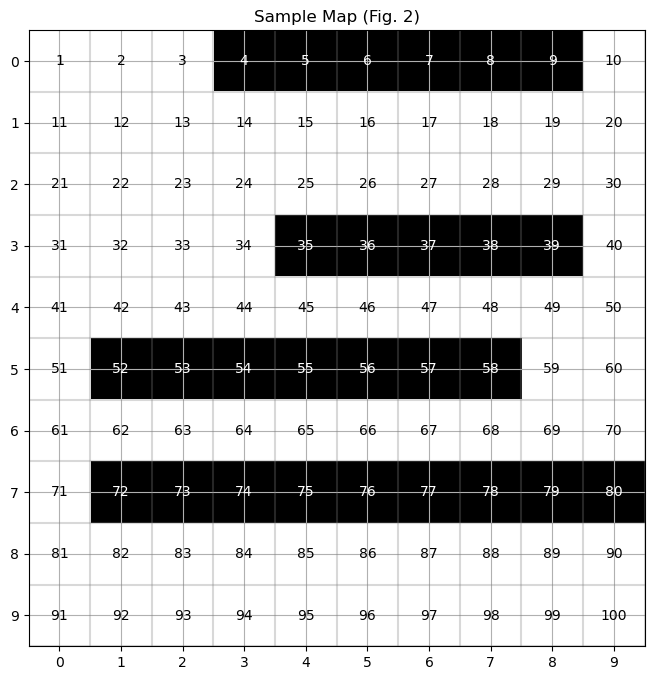

In [ ]:
def main():
    # 지도 생성
    map_data = create_map()
    
    # 시작점과 목표점 설정 (그림 2에서 좌상단(1)부터 우하단(100)까지)
    start = 1  # 1번 노드
    goal = 100  # 100번 노드
    
    print("===== 유전자 알고리즘의 수렴 속도 향상을 통한 효과적인 로봇 길 찾기 알고리즘 실험 =====")
    print(f"- 실험 시작 시간: {time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"- 시작 노드: {start}, 목표 노드: {goal}")
    print(f"- 집단 크기: 50, 최대 세대 수: 100")
    print("=" * 80)
    
    # 지도 시각화
    visualize_map(map_data, title="Sample Map (Fig. 2)")
    
    # 알고리즘별 실행 및 결과 비교
    algorithms = {
        "FGA": FGA(map_data, start, goal, pop_size=50, max_gen=100),
        "IGA": IGA(map_data, start, goal, pop_size=50, max_gen=100),
        "KGA": KGA(map_data, start, goal, pop_size=50, max_gen=100),
        "Proposed": ProposedGA(map_data, start, goal, pop_size=50, max_gen=100)
    }
    
    results = {}
    
    for name, algo in algorithms.items():
        print(f"\n{'=' * 30} 알고리즘: {name} {'=' * 30}")
        start_time = time.time()
        best_path, best_distance = algo.evolve()
        end_time = time.time()
        
        results[name] = {
            "path": best_path,
            "distance": best_distance,
            "history": algo.best_history,
            "time": end_time - start_time,
            "path_length": len(best_path)
        }
        
        print(f"실행 시간: {end_time - start_time:.2f}초, 경로 길이: {len(best_path)}개 노드")
        print(f"찾은 경로: {best_path}")
        print("-" * 80)
        
        # 결과 시각화
        visualize_map(map_data, best_path, title=f"{name} Result: Distance = {best_distance:.2f}")
    
    # 표 1의 결과와 비교
    print("\n===== 표 1 비교 결과 =====")
    print("Method | Paper Result | Our Result | Path Length | Runtime (s)")
    print("-------|--------------|-----------|-------------|------------")
    paper_results = {"FGA": 1914, "IGA": 9528, "KGA": 4217, "Proposed": 1275}
    
    for method in ["FGA", "IGA", "KGA", "Proposed"]:
        our_result = results[method]["distance"]
        paper_result = paper_results[method]
        path_length = results[method]["path_length"]
        runtime = results[method]["time"]
        print(f"{method} | {paper_result} | {our_result:.2f} | {path_length} | {runtime:.2f}")
    
    print("\n===== 알고리즘 성능 요약 =====")
    # 각 알고리즘 간의 성능 비교
    best_algorithm = min(results.items(), key=lambda x: x[1]["distance"])[0]
    fastest_converge = min(results.items(), key=lambda x: sum(x[1]["history"][:33]))[0]
    
    print(f"최단 경로 거리: {best_algorithm} ({results[best_algorithm]['distance']:.2f})")
    print(f"가장 빠른 수렴: {fastest_converge}")
    
    # 초기 세대 수렴성 비교
    print("\n초기 수렴 성능 (초반 33세대 경로 감소량):")
    for name, result in results.items():
        early_improvement = result["history"][0] - result["history"][32]
        print(f"- {name}: {early_improvement:.2f}")
    
    # 세대에 따른 최단 경로 길이 변화 그래프 (그림 5)
    plt.figure(figsize=(10, 6))
    for name, result in results.items():
        plt.plot(result["history"], label=name)
    
    plt.xlabel("Generation")
    plt.ylabel("Shortest Path Distance")
    plt.title("Shortest Path Distance with the Generation for Each Genetic Algorithm")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 구간별 최단 경로의 감소량 (그림 6)
    plt.figure(figsize=(10, 6))
    bar_width = 0.2
    index = np.arange(3)  # 초반, 중반, 후반
    
    for i, (name, result) in enumerate(results.items()):
        # 세 구간으로 나누기
        history = result["history"]
        interval1 = history[0] - history[33]
        interval2 = history[33] - history[66]
        interval3 = history[66] - history[-1]
        
        plt.bar(index + i * bar_width, [interval1, interval2, interval3], 
                width=bar_width, label=name)
    
    plt.xlabel("Interval")
    plt.ylabel("Decrement of Shortest Path Distance")
    plt.title("Decrement of Shortest Path Distance in Each Interval")
    plt.xticks(index + bar_width * 1.5, ["Early (1-33)", "Middle (34-66)", "Late (67-100)"])
    plt.legend()
    plt.grid(True, axis='y')
    plt.show()
    
    print(f"\n실험 종료 시간: {time.strftime('%Y-%m-%d %H:%M:%S')}")

if __name__ == "__main__":
    main()